# A2 extra: fractional differintegration of arbitrary order

*Standalone demonstrator for Appendix 2 (see `../A2_semiintegration.ipynb`).*

Semi-integration ($q=-\tfrac12$) and semi-differentiation ($q=+\tfrac12$) are
two members of a continuous family of operators $D^{q}$ for any real $q$.
Honeychurch illustrates this by extending Mathematica's `D` to non-integer
orders of a power $x^m$ via the gamma generalisation of the power rule. Here we
use the **Grünwald–Letnikov** operator
`serm.semiintegration.fractional_integrodifferentiate`, check it against that
closed form, and show the order $q$ continuously morphing a voltammetric current
from a sigmoid into an ever-sharper peak.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../..'))
# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as Gamma
from serm.semiintegration import fractional_integrodifferentiate, semi_derivative


In [2]:
from serm.sourcelinks import source_links
source_links(fractional_integrodifferentiate, semi_derivative)

## 1. Closed-form check: the gamma power rule

$$D^{q}\,x^{m}=\frac{\Gamma(m+1)}{\Gamma(m-q+1)}\,x^{m-q}.$$

This holds for any real $q$ (negative for an integral, positive for a
derivative). We sweep several orders on $x^3$ and compare the numerical operator
with the exact expression on the upper portion of the grid (the G–L sum is
end-loaded; the lower edge carries the startup transient).

In [3]:
m = 3.0
x = np.linspace(0.0, 4.0, 12000); dx = x[1] - x[0]
y = x ** m
orders = [-0.5, -0.25, 0.25, 0.5, 0.75, 1.0]
for q in orders:
    num = fractional_integrodifferentiate(y, dx, order=q)
    exact = Gamma(m + 1) / Gamma(m - q + 1) * x ** (m - q)
    sl = slice(int(0.6 * x.size), None)
    rel = np.max(np.abs(num[sl] - exact[sl]) / (np.abs(exact[sl]) + 1e-12))
    print(f"q = {q:+.2f}:  max rel. error = {rel:.2e}")
    assert rel < 5e-3, f"power-rule check failed at q={q}"
print("Tier 1 passed: G-L operator matches the gamma power rule for all orders.")


q = -0.50:  max rel. error = 1.22e-04
q = -0.25:  max rel. error = 5.64e-05


q = +0.25:  max rel. error = 4.77e-05
q = +0.50:  max rel. error = 8.68e-05
q = +0.75:  max rel. error = 1.17e-04


q = +1.00:  max rel. error = 1.39e-04
Tier 1 passed: G-L operator matches the gamma power rule for all orders.


## 2. Continuous morph of an LSV current

We build a reversible LSV current ($i_{\mathrm{LSV}}=D^{+1/2}\theta$ with the
Nernst sigmoid $\theta$) and apply $D^q$ for a range of $q$. As $q$ rises from
$-\tfrac12$ (sigmoid) through $0$ (the current itself) to $+\tfrac12$ (symmetric
peak), the response continuously sharpens.

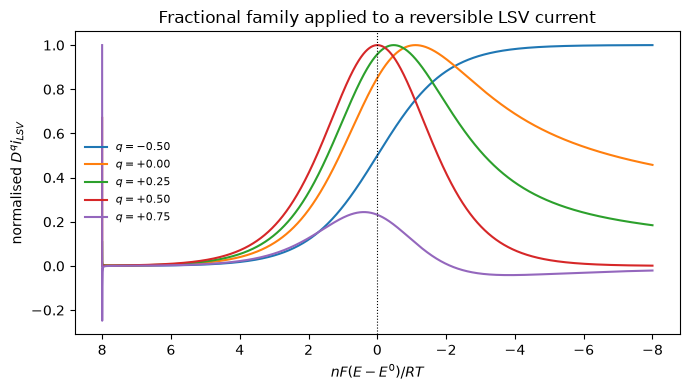

In [4]:
p = np.linspace(8.0, -8.0, 8000); tau = np.linspace(0.0, 1.0, p.size)
dtau = tau[1] - tau[0]
theta = 1.0 / (1.0 + np.exp(p))
i_lsv = semi_derivative(theta, dtau)

fig, ax = plt.subplots(figsize=(7, 4))
for q in [-0.5, 0.0, 0.25, 0.5, 0.75]:
    g = i_lsv.copy() if q == 0.0 else fractional_integrodifferentiate(i_lsv, dtau, order=q)
    g = g / np.max(np.abs(g))
    ax.plot(p, g, label=fr"$q={q:+.2f}$")
ax.axvline(0.0, ls=":", color="k", lw=0.8); ax.invert_xaxis()
ax.set(xlabel="$nF(E-E^0)/RT$", ylabel="normalised $D^q i_{LSV}$",
       title="Fractional family applied to a reversible LSV current")
ax.legend(frameon=False, fontsize=8); fig.tight_layout(); plt.show()


## Validation

**Tier 2/3, monotone sharpening.** Increasing the differintegration order
narrows the response. We assert that the full-width at half-maximum of the
positive lobe decreases monotonically from $q=0$ (the LSV current) to
$q=+\tfrac12$ (the symmetric peak), and that the $q=+\tfrac12$ peak is centred at
$E^0$ ($p=0$).

In [5]:
def fwhm(sig):
    s = sig / np.max(sig)
    imax = int(np.argmax(s)); half = 0.5
    l = imax
    while l > 0 and s[l] > half: l -= 1
    r = imax
    while r < s.size - 1 and s[r] > half: r += 1
    return r - l, imax

widths = []
for q in [0.0, 0.25, 0.5]:
    g = i_lsv.copy() if q == 0.0 else fractional_integrodifferentiate(i_lsv, dtau, order=q)
    g = np.clip(g, 0, None)   # positive lobe only
    w, _ = fwhm(g)
    widths.append(w)
    print(f"q = {q:+.2f}: FWHM = {w} samples")
assert widths[0] > widths[1] > widths[2], "FWHM did not shrink monotonically"

# q = +1/2 peak centred at E0.
peak = semi_derivative(i_lsv, dtau)
imax = int(np.argmax(peak))
assert abs(p[imax]) < 0.05, f"semi-derivative peak not at E0: p={p[imax]:.3f}"
print(f"semi-derivative peak at p = {p[imax]:.4f} (= E0).")
print("Tier 2/3 passed: order increases -> response sharpens; peak at E0.")


q = +0.00: FWHM = 3967 samples
q = +0.25: FWHM = 2281 samples
q = +0.50: FWHM = 1764 samples
semi-derivative peak at p = -0.0010 (= E0).
Tier 2/3 passed: order increases -> response sharpens; peak at E0.


<!-- nav-footer -->

---

[← Appendix 2 — Semi-integration and fractional calculus](../A2_semiintegration.ipynb)

[Contents (README)](../../README.md)